# Sentiment Analyis of Grimm Brothers

## Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML


In [3]:
OHCO = ['doc_title','para_num','sentence_num','token_num']

In [4]:
# Import SALEX from kaggle for sentiment analysis
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()
SALEX = pd.read_csv('data/salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX.head()

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


In [5]:
BOW_para = pd.read_csv('data/pg2591-para_BOW.csv').set_index(OHCO[:1])
BOW_para.head()

,para_num,term_str,n
doc_title,,,
ASHPUTTEL,0,a,4
ASHPUTTEL,0,about,1
ASHPUTTEL,0,afterwards,1
ASHPUTTEL,0,again,1
ASHPUTTEL,0,all,1


In [6]:
BOW_stories = pd.read_csv('data/pg2591-story_BOW.csv').set_index(OHCO[:1])
BOW_stories.head()

,term_str,n
doc_title,,
ASHPUTTEL,_my_,1
ASHPUTTEL,a,21
ASHPUTTEL,about,3
ASHPUTTEL,after,2
ASHPUTTEL,afterwards,1


In [7]:
DOCS = pd.read_csv('data/pg2591-DOCS.csv')
DOCS.head()

,doc_id,doc_title,doc_str
0,1,THE GOLDEN BIRD,"\n\nA certain king had a beautiful garden, and..."
1,2,HANS IN LUCK,\n\nSome men are born to good luck: all they d...
2,3,JORINDA AND JORINDEL,"\n\nThere was once an old castle, that stood i..."
3,4,THE TRAVELLING MUSICIANS,\n\nAn honest farmer had once an ass that had ...
4,5,OLD SULTAN,"\n\nA shepherd had a faithful dog, called Sult..."


In [8]:
VOCAB = pd.read_csv('data/pg2591-VOCAB.csv')
VOCAB.head()

,term_str,n,p,i,n_chars,max_pos_group,max_pos,porter_stem,stop,df,idf,tfidf_mean,dfidf,dp,di,dh
0,the,6927,0.068553,3.866638,3,DT,DT,the,1,62,0.0,0.0,0.0,1.0,0.0,0.0
1,and,5433,0.053768,4.217119,3,CC,CC,and,1,62,0.0,0.0,0.0,1.0,0.0,0.0
2,to,2662,0.026344,5.246358,2,TO,TO,to,1,62,0.0,0.0,0.0,1.0,0.0,0.0
3,he,2093,0.020713,5.593296,2,PR,PRP,he,1,62,0.0,0.0,0.0,1.0,0.0,0.0
4,a,1909,0.018892,5.726051,1,DT,DT,a,1,62,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
TOKENS= pd.read_csv('/Users/graceegeorge/TextasDataFinalProject/data/p2591-TOKENS.csv').set_index(OHCO).dropna()
TOKENS.head()

pos_tuple pos token_str  \
doc_title para_num sentence_num token_num                                 
ASHPUTTEL 0        0            0           ('The', 'DT')  DT       The   
                                1          ('wife', 'NN')  NN      wife   
                                2            ('of', 'IN')  IN        of   
                                3             ('a', 'DT')  DT         a   
                                4          ('rich', 'JJ')  JJ      rich   

                                          term_str pos_group  
doc_title para_num sentence_num token_num                     
ASHPUTTEL 0        0            0              the        DT  
                                1             wife        NN  
                                2               of        IN  
                                3                a        DT  
                                4             rich        JJ

In [10]:
VOCAB = pd.read_csv('data/pg2591-VOCAB.csv')
VOCAB.head()

,term_str,n,p,i,n_chars,max_pos_group,max_pos,porter_stem,stop,df,idf,tfidf_mean,dfidf,dp,di,dh
0,the,6927,0.068553,3.866638,3,DT,DT,the,1,62,0.0,0.0,0.0,1.0,0.0,0.0
1,and,5433,0.053768,4.217119,3,CC,CC,and,1,62,0.0,0.0,0.0,1.0,0.0,0.0
2,to,2662,0.026344,5.246358,2,TO,TO,to,1,62,0.0,0.0,0.0,1.0,0.0,0.0
3,he,2093,0.020713,5.593296,2,PR,PRP,he,1,62,0.0,0.0,0.0,1.0,0.0,0.0
4,a,1909,0.018892,5.726051,1,DT,DT,a,1,62,0.0,0.0,0.0,1.0,0.0,0.0


## Get VOCAB sentiment analysis

In [11]:
# Conducted on token table by following example "Sentiment Analysis with Novels"
VOCAB_SA = VOCAB.join(SALEX, on='term_str', how='left') #.fillna(0)
VOCAB_SA.set_index('term_str',inplace=True)
VOCAB_SA

,n,p,i,n_chars,max_pos_group,max_pos,porter_stem,stop,df,idf,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
the,6927,0.068553,3.866638,3,DT,DT,the,1,62,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
and,5433,0.053768,4.217119,3,CC,CC,and,1,62,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,2662,0.026344,5.246358,2,TO,TO,to,1,62,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
he,2093,0.020713,5.593296,2,PR,PRP,he,1,62,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a,1909,0.018892,5.726051,1,DT,DT,a,1,62,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
bath,1,0.000010,16.624653,4,NN,NN,bath,0,1,5.954196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathinghouse,1,0.000010,16.624653,12,NN,NN,bathinghous,0,1,5.954196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrive,1,0.000010,16.624653,6,VB,VB,arriv,0,1,5.954196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Turn in BOW_SA
Did tokens instead on BOW because it made the join easier

In [12]:
TOKENS_SA = TOKENS.join(VOCAB_SA, on='term_str', how='left').fillna(0)
# TOKENS_SA['anger'] = TOKENS_SA['anger'] * TOKENS_SA['n']
# TOKENS_SA['anticipation'] = TOKENS_SA['anticipation'] * TOKENS_SA['n']
# TOKENS_SA['disgust'] = TOKENS_SA['disgust'] * TOKENS_SA['n']
# TOKENS_SA['fear'] = TOKENS_SA['fear'] * TOKENS_SA['n']
# TOKENS_SA['joy'] = TOKENS_SA['joy'] * TOKENS_SA['n']
# TOKENS_SA['negative'] = TOKENS_SA['negative'] * TOKENS_SA['n']
# TOKENS_SA['positive'] = TOKENS_SA['positive'] * TOKENS_SA['n']
# TOKENS_SA['sadness'] = TOKENS_SA['sadness'] * TOKENS_SA['n']
# TOKENS_SA['surprise'] = TOKENS_SA['surprise'] * TOKENS_SA['n']
# TOKENS_SA['trust'] = TOKENS_SA['trust'] * TOKENS_SA['n']
# TOKENS_SA['sentiment']= TOKENS_SA['sentiment'] * TOKENS_SA['n']
TOKENS_SA

pos_tuple  pos token_str  \
doc_title para_num sentence_num token_num                                   
ASHPUTTEL 0        0            0            ('The', 'DT')   DT       The   
                                1           ('wife', 'NN')   NN      wife   
                                2             ('of', 'IN')   IN        of   
                                3              ('a', 'DT')   DT         a   
                                4           ('rich', 'JJ')   JJ      rich   
...                                                    ...  ...       ...   
TOM THUMB 21       3            40            ('s', 'VBZ')  VBZ         s   
                                41            ('no', 'DT')   DT        no   
                                42         ('place', 'NN')   NN     place   
                                43          ('like', 'IN')   IN      like   
                                44          ('HOME', 'NN')   NN      HOME   

                                          term_str pos_group     n         p  \
doc_title para_num sentence_num token_num                                      
ASHPUTTEL 0        0            0              the        DT  6927  0.068553   
                                1             wife        NN   150  0.001484   
                                2               of        IN  1352  0.013380   
                                3                a        DT  1909  0.018892   
                                4             rich        JJ    21  0.000208   
...                                            ...       ...   ...       ...   
TOM THUMB 21       3            40               s        VB   361  0.003573   
                                41              no        DT   310  0.003068   
                                42           place        NN    40  0.000396   
                                43            like        IN   125  0.001237   
                                44            home        NN   180  0.001781   

                                                   i  n_chars max_pos_group  \
doc_title para_num sentence_num token_num                                     
ASHPUTTEL 0        0            0           3.866638        3            DT   
                                1           9.395834        4            NN   
                                2           6.223773        2            IN   
                                3           5.726051        1            DT   
                                4          12.232335        4            JJ   
...                                              ...      ...           ...   
TOM THUMB 21       3            40          8.128798        1            NN   
                                41          8.348528        2            DT   
                                42         11.302725        5            NN   
                                43          9.658868        4            IN   
                                44          9.132800        4            NN   

                                           ... anticipation disgust  fear  \
doc_title para_num sentence_num token_num  ...                              
ASHPUTTEL 0        0            0          ...          0.0     0.0   0.0   
                                1          ...          0.0     0.0   0.0   
                                2          ...          0.0     0.0   0.0   
                                3          ...          0.0     0.0   0.0   
                                4          ...          0.0     0.0   0.0   
...                                        ...          ...     ...   ...   
TOM THUMB 21       3            40         ...          0.0     0.0   0.0   
                                41         ...          0.0     0.0   0.0   
                                42         ...          0.0     0.0   0.0   
                                43         ...          0.0     0.0   0.0   
                                44         ...        

In [13]:
STORY_SA = TOKENS_SA.fillna(0).groupby('doc_title')[emo_cols].mean()
STORY_SA


,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
doc_title,,,,,,,,,
ASHPUTTEL,0.005794,0.019699,0.007725,0.006566,0.033217,0.016222,0.005794,0.026651,0.010815
BRIAR ROSE,0.006588,0.017128,0.003953,0.009223,0.023715,0.011199,0.009881,0.013834,0.010540
CAT AND MOUSE IN PARTNERSHIP,0.001015,0.030457,0.011168,0.003046,0.032487,0.014213,0.007107,0.035533,0.023350
CAT-SKIN,0.006554,0.015449,0.006554,0.007022,0.028558,0.013109,0.010300,0.018727,0.009831
CLEVER ELSIE,0.005979,0.012706,0.006726,0.011211,0.021674,0.021674,0.005979,0.012706,-0.004484
...,...,...,...,...,...,...,...,...,...
THE WEDDING OF MRS. FOX - PART II,0.010638,0.023936,0.007979,0.010638,0.023936,0.007979,0.021277,0.026596,0.013298
THE WHITE SNAKE,0.016119,0.022939,0.007440,0.014259,0.034098,0.013639,0.018599,0.024179,0.011779
THE WILLOW-WREN AND THE BEAR,0.035987,0.014177,0.017448,0.043621,0.017448,0.015267,0.010905,0.014177,-0.017448


## Make a Visualization

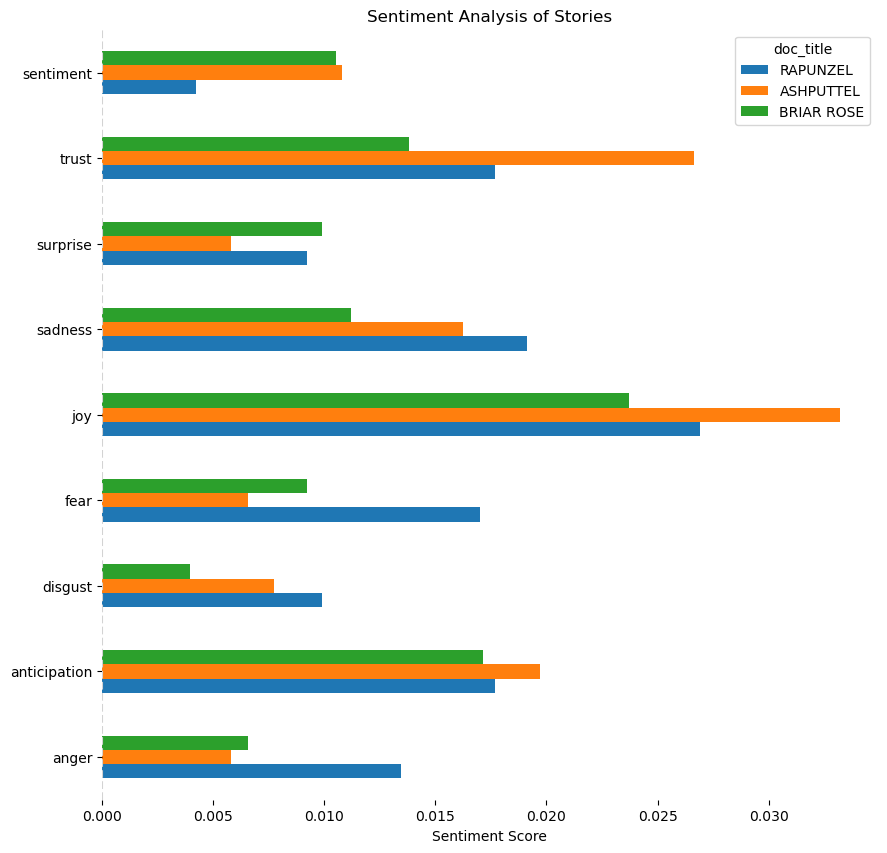

In [14]:
ax = STORY_SA.loc[['RAPUNZEL','ASHPUTTEL','BRIAR ROSE']].T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
ax.set_xlabel('Sentiment Score')
ax.set_title('Sentiment Analysis of Stories')
sns.despine(left=True, bottom=True)
plt.savefig('sentiment_analysis.png')
plt.show()
